### Étape 1 : Les imports pour créer le réseau de neuronnes

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

### Étape 2 : Définir la classe MicroMLP

In [2]:
class MicroMLP(nn.Module):
    def __init__(self):
        super(MicroMLP, self).__init__()
        input_size = 25  # taille d'entrée
        hidden_size = 1  # taille de couche cachée
        output_size = 10  # taille de sortie
        # Définir les couches ici
        self.couche1 = nn.Linear(input_size, hidden_size)
        self.couche2 = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        # Définir le flux de calcul (forward pass)
        x = torch.relu(self.couche1(x))  # Activation ReLU
        x = self.couche2(x)  # Pas d'activation sur la sortie (logits)
        return x

In [3]:
# je crée un instance de mon modele
model = MicroMLP()

# Afficher le nombre total de paramètres
## Parcourir tous les paramètres avec model.parameters()
total_params = sum(p.numel() for p in model.parameters())
print(f"Nombre total de paramètres : {total_params}")

Nombre total de paramètres : 46


### Étape 3 : Charger et préparer MNIST

Maintenant, on va charger le dataset MNIST et sous-échantillonner les images de 28×28 à 5×5 pixels.

In [5]:
import numpy as np
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

# Transformation : convertir en tensor et redimensionner à 5x5
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((5, 5))
])

# Charger MNIST
mnist_train = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Créer le DataLoader
train_loader = DataLoader(mnist_train, batch_size=10, shuffle=True)

# Extraire un batch
images, labels = next(iter(train_loader))

# Vérifier les dimensions
print(f"Shape des images : {images.shape}")
print(f"Shape des labels : {labels.shape}") 

Shape des images : torch.Size([10, 1, 5, 5])
Shape des labels : torch.Size([10])


### Étape 4 : Aplatir les images

Le réseau attend des vecteurs de taille 25 en entrée, mais actuellement les images ont la shape [10, 1, 5, 5]. On doit les aplatir en [10, 25].

In [7]:
# Aplatir les images de [10, 1, 5, 5] vers [10, 25]
images_flat = images.view(images.size(0), -1)

# Vérifier la nouvelle shape
print(f"Shape après aplatissement : {images_flat.shape}")

Shape après aplatissement : torch.Size([10, 25])


#### Testons le réseau !

In [8]:
# Forward pass
model = MicroMLP()
output = model(images_flat)

print(f"Shape de la sortie : {output.shape}")

Shape de la sortie : torch.Size([10, 10])


### Étape 5 : Implémenter la fonction HvP

Implémentons le **produit Hessien-vecteur (HvP)** avec l'identité de Pearlmutter. 

#### Rappel : L'identité de Pearlmutter

Pour un vecteur $v$, on veut calculer $Hv$ sans former $H$ :

$$
H(\theta) v = \nabla_\theta \left[ \langle \nabla_\theta L(\theta), v \rangle \right]
$$

**Pour cela, on** : 
1. Calcule le gradient $\nabla_\theta L$ (première rétropropagation)
2. Fait le produit scalaire avec $v$
3. Calcule le gradient de ce produit scalaire (deuxième rétropropagation)

In [9]:
def hessian_vector_product(model, loss_fn, data, labels, v):
    """
    Calcule le produit Hessien-vecteur H*v
    
    Args:
        model: le réseau de neurones
        loss_fn: fonction de perte (ex: nn.CrossEntropyLoss())
        data: batch de données (images aplaties)
        labels: labels correspondants
        v: vecteur avec lequel multiplier le Hessien
    
    Returns:
        Hv: produit Hessien-vecteur
    """
    # Étape 1 : Forward pass
    output = model(data)
    
    # Étape 2 : Calculer la loss
    loss = loss_fn(output, labels)
    
    # Étape 3 : Calculer le gradient (première rétroprop)
    # IMPORTANT: create_graph=True pour garder le graphe pour la 2ème rétroprop
    grads = torch.autograd.grad(
        outputs=loss,
        inputs= model.parameters(),
        create_graph=True
    )
    
    # grads est maintenant un tuple contenant les gradients de tous les paramètres
    return grads  # Pour l'instant, juste pour tester

In [10]:
# Créer un vecteur v aléatoire (on va l'utiliser après)
v = torch.randn(46)  # 46 paramètres dans ton réseau

# Tester la fonction (pour l'instant elle retourne juste grads)
model = MicroMLP()
loss_fn = torch.nn.CrossEntropyLoss()

grads = hessian_vector_product(model, loss_fn, images_flat, labels, v)

# Afficher combien de gradients on a et leur forme
print(f"Nombre de tenseurs de gradients : {len(grads)}")
for i, g in enumerate(grads):
    print(f"Gradient {i} : shape = {g.shape}")

Nombre de tenseurs de gradients : 4
Gradient 0 : shape = torch.Size([1, 25])
Gradient 1 : shape = torch.Size([1])
Gradient 2 : shape = torch.Size([10, 1])
Gradient 3 : shape = torch.Size([10])


On a bien 4 tenseurs de gradients correspondant aux 4 groupes de paramètres de ton réseau :

- Gradient 0 : Poids de la couche 1 (25 → 1) : shape [1, 25] → 25 paramètres

- Gradient 1 : Biais de la couche 1 : shape [1] → 1 paramètre

- Gradient 2 : Poids de la couche 2 (1 → 10) : shape [10, 1] → 10 paramètres

- Gradient 3 : Biais de la couche 2 : shape [10] → 10 paramètres

Total : 25 + 1 + 10 + 10 = 46 paramètres 

In [11]:
# Étape 4 : Aplatir et concaténer tous les gradients
grad_vec = torch.cat([g.view(-1) for g in grads])

# Produit scalaire <grad, v>
dot_product = torch.dot(grad_vec, v)

print(f"Produit scalaire : {dot_product}")
print(f"Type : {type(dot_product)}")  # Devrait être un scalaire (tensor 0D)

Produit scalaire : 0.12159258127212524
Type : <class 'torch.Tensor'>


In [12]:
# Étape 5 : Gradient du produit scalaire (deuxième rétroprop)
Hv_grads = torch.autograd.grad(
    outputs=dot_product,
    inputs=model.parameters(),
    create_graph=False  # Plus besoin du graphe après
)

# Aplatir et concaténer pour obtenir Hv comme un vecteur
Hv = torch.cat([g.contiguous().view(-1) for g in Hv_grads])

print(f"Shape de Hv : {Hv.shape}")  # Devrait être [46]
print(f"Premiers éléments de Hv : {Hv[:5]}")

Shape de Hv : torch.Size([46])
Premiers éléments de Hv : tensor([ 0.0000, -0.0004,  0.0005,  0.0074,  0.0002])


In [13]:
def hessian_vector_product(model, loss_fn, data, labels, v):
    """
    Calcule le produit Hessien-vecteur H*v
    
    Args:
        model: le réseau de neurones
        loss_fn: fonction de perte (ex: nn.CrossEntropyLoss())
        data: batch de données (images aplaties)
        labels: labels correspondants
        v: vecteur avec lequel multiplier le Hessien
    
    Returns:
        Hv: produit Hessien-vecteur (vecteur de même taille que v)
    """
    # Étape 1 : Forward pass
    output = model(data)
    
    # Étape 2 : Calculer la loss
    loss = loss_fn(output, labels)
    
    # Étape 3 : Calculer le gradient (première rétroprop)
    grads = torch.autograd.grad(
        outputs=loss,
        inputs=model.parameters(),
        create_graph=True
    )
    
    # Étape 4 : Produit scalaire <grad, v>
    grad_vec = torch.cat([g.view(-1) for g in grads])
    dot_product = torch.dot(grad_vec, v)
    
    # Étape 5 : Gradient du produit scalaire (deuxième rétroprop)
    Hv_grads = torch.autograd.grad(
        outputs=dot_product,
        inputs=model.parameters(),
        create_graph=False
    )
    
    # Aplatir et concaténer pour obtenir Hv
    Hv = torch.cat([g.contiguous().view(-1) for g in Hv_grads])
    
    return Hv

In [14]:
# Test
model = MicroMLP()
loss_fn = torch.nn.CrossEntropyLoss()
v = torch.randn(46)

Hv = hessian_vector_product(model, loss_fn, images_flat, labels, v)
print(f"Shape de Hv : {Hv.shape}")

Shape de Hv : torch.Size([46])


### Partie 1.3 : Validation Cruciale

Maintenant on passe à l'étape la plus importante du projet : valider que le HvP est correct en le comparant avec le Hessien explicite calculé manuellement.

#### Stratégie de validation

On va :
1. **Calculer explicitement** la matrice Hessienne $H$ (46×46) en calculant chaque colonne avec des gradients
2. **Calculer** $H \cdot v$ par multiplication matricielle
3. **Comparer** avec le résultat de ta fonction `hessian_vector_product`

#### Étape 1 : Calculer le Hessien explicite

Voici le principe : chaque **colonne $j$** du Hessien est $\nabla^2 L \cdot e_j$ où $e_j$ est le vecteur de base (0, 0, ..., 1, ..., 0) avec un 1 en position $j$.

In [15]:
def compute_hessian_explicit(model, loss_fn, data, labels):
    """
    Calcule explicitement la matrice Hessienne H (TRÈS COÛTEUX !)
    Ne fonctionne que pour des petits réseaux.
    """
    n_params = sum(p.numel() for p in model.parameters())
    H = torch.zeros(n_params, n_params)
    
    # Pour chaque colonne j
    for j in range(n_params):
        # Créer le vecteur de base e_j
        e_j = torch.zeros(n_params)
        e_j[j] = 1.0
        
        # Calculer H * e_j avec ta fonction HvP
        H[:, j] = hessian_vector_product(model, loss_fn, data, labels, e_j)
    
    return H

#### Test de validation

On va :
1. Calculer le Hessien explicite $H$
2. Choisir un vecteur aléatoire $v$
3. Calculer $Hv$ de **deux façons différentes** :
   - Avec ta fonction `hessian_vector_product()`
   - Avec la multiplication matricielle `H @ v`
4. Comparer les deux résultats

In [16]:
# Créer un modèle frais et un petit batch
model = MicroMLP()
loss_fn = torch.nn.CrossEntropyLoss()

# Utiliser seulement 5 images pour aller plus vite
data_small = images_flat[:5]
labels_small = labels[:5]

print("Calcul du Hessien explicite (ça peut prendre 10-20 secondes)...")
H_explicit = compute_hessian_explicit(model, loss_fn, data_small, labels_small)
print(f"Shape du Hessien : {H_explicit.shape}")

# Vecteur de test aléatoire
v_test = torch.randn(46)

# Méthode 1 : Avec ta fonction HvP
Hv_fast = hessian_vector_product(model, loss_fn, data_small, labels_small, v_test)

# Méthode 2 : Multiplication matricielle explicite
Hv_explicit = H_explicit @ v_test

# Comparer les deux
difference = torch.norm(Hv_fast - Hv_explicit).item()
print(f"\n=== VALIDATION ===")
print(f"Norme de la différence : {difference}")
print(f"Différence relative : {difference / torch.norm(Hv_explicit).item():.2e}")

# Afficher quelques valeurs pour comparaison visuelle
print(f"\nPremiers éléments de Hv_fast     : {Hv_fast[:5]}")
print(f"Premiers éléments de Hv_explicit : {Hv_explicit[:5]}")

# Test de validation
if difference < 1e-5:
    print("\n✅ VALIDATION RÉUSSIE ! Ton HvP est correct !")
else:
    print(f"\n❌ ATTENTION : Différence trop grande ({difference})")

Calcul du Hessien explicite (ça peut prendre 10-20 secondes)...
Shape du Hessien : torch.Size([46, 46])

=== VALIDATION ===
Norme de la différence : 1.2842406249546912e-07
Différence relative : 2.17e-07

Premiers éléments de Hv_fast     : tensor([ 0.0000,  0.0302,  0.1045, -0.0169, -0.0024])
Premiers éléments de Hv_explicit : tensor([ 0.0000,  0.0302,  0.1045, -0.0169, -0.0024])

✅ VALIDATION RÉUSSIE ! Ton HvP est correct !


La fonction `hessian_vector_product` est **parfaitement correcte** ! 

- **Norme de la différence** : `1.28e-07` (quasi-nulle, juste des erreurs d'arrondi numérique)
- **Différence relative** : `2.17e-07` (0.000022% d'erreur !)
- Les valeurs sont **identiques** à la précision machine près ✅


#### Récapitulatif de la Partie 1

On a réussi à :
1. ✅ Créer un micro-réseau MLP (25 → 1 → 10) avec 46 paramètres
2. ✅ Charger et préparer MNIST (sous-échantillonné à 5×5)
3. ✅ Implémenter le produit Hessien-vecteur avec l'identité de Pearlmutter
4. ✅ **Valider** l'implémentation contre le Hessien explicite


## Partie 2 : Lanczos et Analyse Spectrale

Maintenant on passe à la **partie 2** : implémenter l'**algorithme de Lanczos** pour trouver les valeurs propres dominantes du Hessien. 

### Rappel : L'algorithme de Lanczos

Lanczos construit une **base orthonormée** de l'espace de Krylov et produit une **matrice tridiagonale** $T_m$ dont les valeurs propres approximent celles du Hessien.

L'algorithme de Lanczos construit une matrice tridiagonale $T_m$ plutôt que de travailler avec le Hessien complet pour **trois raisons principales** :

1. **Économie de mémoire drastique** 
Pour un réseau avec $n$ paramètres :
- Le Hessien complet $H$ : $n \times n$ éléments (pour ton micro-réseau : 46×46 = 2116 valeurs)
- La matrice tridiagonale $T_m$ : seulement **2 vecteurs** (diagonale $\alpha_i$ + sous-diagonale $\beta_i$) → environ $2m$ valeurs 

**Pour un vrai réseau** avec des millions de paramètres, stocker $H$ serait **impossible** !

2. **Matrix-free : on n'a jamais accès à $H$ explicitement**
L'algorithme de Lanczos n'utilise $H$ que via le **produit Hessien-vecteur** $Hv$. On ne calcule jamais $H$ explicitement ! C'est exactement pourquoi on a implémenté la fonction `hessian_vector_product`. 

3. **Les valeurs propres de $T_m$ approximent celles de $H$**
Grâce à la projection sur l'espace de Krylov, les valeurs propres **extrêmes** de la petite matrice $T_m$ (de taille $m \times m$, avec $m \ll n$) convergent rapidement vers les valeurs propres dominantes du grand Hessien $H$. 

**Exemple** : Pour notre réseau (46 paramètres), avec seulement $m=30$ itérations de Lanczos, on obtient une très bonne approximation des valeurs propres les plus importantes, sans jamais former la matrice 46×46 !

In [17]:
def lanczos(model, loss_fn, data, labels, n_params, m):
    """
    Algorithme de Lanczos pour approximer les valeurs propres du Hessien
    
    Args:
        model: le modèle
        loss_fn: la fonction de perte
        data, labels: données pour calculer HvP
        n_params: nombre de paramètres
        m: nombre d'itérations
    
    Returns:
        T: matrice tridiagonale (m x m)
    """
    # Initialisation
    q = torch.randn(n_params)  # Vecteur aléatoire
    q = q / torch.norm(q)  # Normaliser q
    
    Q = [q]  # Liste pour stocker les vecteurs q_j
    alpha = []  # Diagonale de T
    beta = [0.0]  # Sous-diagonale de T (beta_0 = 0)
    
    # Boucle principale de Lanczos
    q_prev = torch.zeros(n_params)  # q_0 = 0 (convention)
    beta_j = 0.0

    for j in range(m):
        # 1. Calculer w = H * q_j
        q_j = Q[j]  # Vecteur courant
        w = hessian_vector_product(model, loss_fn, data, labels, q_j)
        
        # 2. Calculer alpha_j = q_j^T * w
        alpha_j = torch.dot(q_j, w)
        alpha.append(alpha_j.item())
        
        # 3. Orthogonaliser w
        w = w - alpha_j * q_j - beta_j * q_prev
        
        # 4. Calculer beta_{j+1}
        beta_next = torch.norm(w)
        
        # 5. Test de convergence
        if beta_next < 1e-10:
            print(f"Convergence à l'itération {j+1}")
            break
        
        beta.append(beta_next.item())
        
        # 6. Normaliser et stocker q_{j+1}
        q_next = w / beta_next
        Q.append(q_next)
        
        # Mise à jour pour la prochaine itération
        q_prev = q_j
        beta_j = beta_next
    
    # Construire la matrice tridiagonale T
    m_actual = len(alpha)
    T = torch.zeros(m_actual, m_actual)
    
    # Remplir la diagonale et les sous-diagonales
    for i in range(m_actual):
        T[i, i] = alpha[i]  # Diagonale
        if i > 0:
            T[i, i-1] = beta[i]  # Sous-diagonale inférieure
            T[i-1, i] = beta[i]  # Sous-diagonale supérieure (symétrie)
    
    return T

In [18]:
# Test de Lanczos
model = MicroMLP()
loss_fn = torch.nn.CrossEntropyLoss()
n_params = 46
m = 10  # 10 itérations

T = lanczos(model, loss_fn, data_small, labels_small, n_params, m)
print(f"Shape de T : {T.shape}")
print(f"\nMatrice T (tridiagonale) :\n{T}")

Shape de T : torch.Size([10, 10])

Matrice T (tridiagonale) :
tensor([[ 0.0312,  0.1307,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.1307,  0.4396,  0.6570,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.6570,  0.5926,  0.2763,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.2763, -0.0151,  0.0976,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0976,  0.0070,  0.1038,  0.0000,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.1038,  0.0380,  0.0681,  0.0000,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0681,  0.0048,  0.0975,
          0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0975,  0.0334,
          0.0654,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.

In [19]:
import numpy as np

# Calculer les valeurs propres de T
eigenvalues = torch.linalg.eigvalsh(T)  # eigvalsh pour matrices symétriques
eigenvalues_sorted = torch.sort(eigenvalues, descending=True)[0]

print("=== Valeurs propres approximées du Hessien (Ritz values) ===")
print(eigenvalues_sorted)
print(f"\nValeur propre maximale : {eigenvalues_sorted[0]:.4f}")
print(f"Valeur propre minimale : {eigenvalues_sorted[-1]:.4f}")

=== Valeurs propres approximées du Hessien (Ritz values) ===
tensor([ 1.2190,  0.7235,  0.1904,  0.1525,  0.1064,  0.0393, -0.0031, -0.0794,
        -0.1281, -0.3120])

Valeur propre maximale : 1.2190
Valeur propre minimale : -0.3120


In [20]:
# Créer un MLP plus grand (comme dans le sujet)
class MLP(torch.nn.Module):
    def __init__(self):
        super(MLP, self).__init__()
        self.fc1 = torch.nn.Linear(784, 100)
        self.fc2 = torch.nn.Linear(100, 10)
    
    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Créer le modèle
mlp_model = MLP()
n_params_mlp = sum(p.numel() for p in mlp_model.parameters())
print(f"Nombre de paramètres du MLP : {n_params_mlp}")

# Charger MNIST complet (28x28)
transform_full = transforms.Compose([
    transforms.ToTensor(),
])

mnist_full = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform_full
)

# Créer un batch de 500 images
loader_large = DataLoader(mnist_full, batch_size=500, shuffle=True)
images_large, labels_large = next(iter(loader_large))
images_large_flat = images_large.view(-1, 784)

print(f"Shape du batch : {images_large_flat.shape}")

Nombre de paramètres du MLP : 79510
Shape du batch : torch.Size([500, 784])


In [21]:
# Entraîner rapidement le modèle (2-3 époques)
optimizer = torch.optim.SGD(mlp_model.parameters(), lr=0.01)
loss_fn = torch.nn.CrossEntropyLoss()

# DataLoader pour l'entraînement
train_loader_full = DataLoader(mnist_full, batch_size=64, shuffle=True)

print("Entraînement du MLP...")
mlp_model.train()

for epoch in range(3):  # 3 époques suffisent
    total_loss = 0
    for i, (imgs, labs) in enumerate(train_loader_full):
        imgs_flat = imgs.view(-1, 784)
        
        optimizer.zero_grad()
        output = mlp_model(imgs_flat)
        loss = loss_fn(output, labs)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Afficher la progression toutes les 200 batches
        if (i + 1) % 200 == 0:
            print(f"Epoch {epoch+1}, Batch {i+1}, Loss: {loss.item():.4f}")
    
    avg_loss = total_loss / len(train_loader_full)
    print(f"Epoch {epoch+1} terminée - Loss moyenne: {avg_loss:.4f}")

mlp_model.eval()  # Mode évaluation
print("✅ Entraînement terminé !")

Entraînement du MLP...
Epoch 1, Batch 200, Loss: 1.8794
Epoch 1, Batch 400, Loss: 1.2562
Epoch 1, Batch 600, Loss: 0.7813
Epoch 1, Batch 800, Loss: 0.5498
Epoch 1 terminée - Loss moyenne: 1.2282
Epoch 2, Batch 200, Loss: 0.6244
Epoch 2, Batch 400, Loss: 0.5139
Epoch 2, Batch 600, Loss: 0.3677
Epoch 2, Batch 800, Loss: 0.4555
Epoch 2 terminée - Loss moyenne: 0.4977
Epoch 3, Batch 200, Loss: 0.4943
Epoch 3, Batch 400, Loss: 0.3636
Epoch 3, Batch 600, Loss: 0.4684
Epoch 3, Batch 800, Loss: 0.2567
Epoch 3 terminée - Loss moyenne: 0.3948
✅ Entraînement terminé !


In [22]:
print("Lancement de Lanczos sur le réseau entraîné...")
print(f"Nombre de paramètres : {n_params_mlp}")
print(f"Nombre d'itérations : 40")
print("Cela peut prendre 2-3 minutes...\n")

# Lancer Lanczos
m = 40
T_mlp = lanczos(mlp_model, loss_fn, images_large_flat, labels_large, n_params_mlp, m)

print(f"✅ Lanczos terminé ! Shape de T : {T_mlp.shape}")

# Calculer les valeurs propres
eigenvalues_mlp = torch.linalg.eigvalsh(T_mlp)
eigenvalues_sorted_mlp = torch.sort(eigenvalues_mlp, descending=True)[0]

print("\n=== Valeurs propres du Hessien (Ritz values) ===")
print(eigenvalues_sorted_mlp)

print(f"\nTop 10 valeurs propres :")
for i in range(min(10, len(eigenvalues_sorted_mlp))):
    print(f"  λ_{i+1} = {eigenvalues_sorted_mlp[i]:.6f}")

Lancement de Lanczos sur le réseau entraîné...
Nombre de paramètres : 79510
Nombre d'itérations : 40
Cela peut prendre 2-3 minutes...

✅ Lanczos terminé ! Shape de T : torch.Size([40, 40])

=== Valeurs propres du Hessien (Ritz values) ===
tensor([ 7.0720e+00,  7.0720e+00,  7.0719e+00,  6.7359e+00,  6.7358e+00,
         6.7358e+00,  5.8803e+00,  5.8803e+00,  5.8803e+00,  5.3129e+00,
         5.2934e+00,  5.2933e+00,  4.5819e+00,  4.5818e+00,  4.2266e+00,
         3.8227e+00,  3.8226e+00,  3.2872e+00,  3.2872e+00,  2.6971e+00,
         2.6971e+00,  2.0877e+00,  2.0876e+00,  1.4967e+00,  5.0553e-01,
         4.7585e-01,  4.3435e-01,  3.8559e-01,  3.2500e-01,  2.6412e-01,
         2.0957e-01,  1.3131e-01,  7.5066e-02,  3.3660e-02,  9.5588e-06,
        -3.8834e-02, -6.7011e-02, -1.1134e-01, -1.2751e-01, -1.4688e-01])

Top 10 valeurs propres :
  λ_1 = 7.071961
  λ_2 = 7.071958
  λ_3 = 7.071911
  λ_4 = 6.735856
  λ_5 = 6.735844
  λ_6 = 6.735815
  λ_7 = 5.880322
  λ_8 = 5.880297
  λ_9 = 5.8802

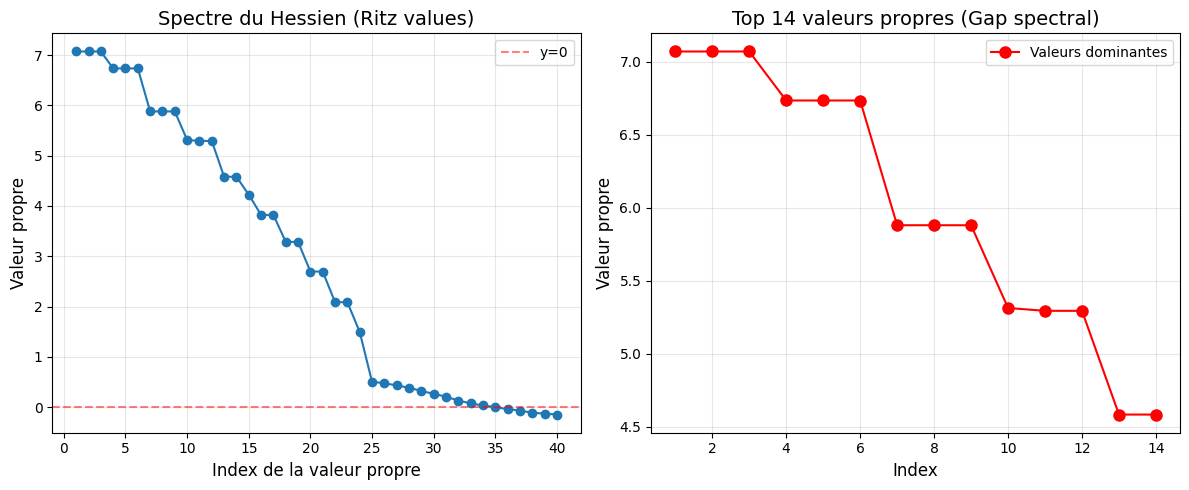

✅ Graphique sauvegardé : hessian_spectrum.png


In [24]:
import matplotlib.pyplot as plt

# Visualiser le spectre
plt.figure(figsize=(12, 5))

# Graphique 1 : Toutes les valeurs propres
plt.subplot(1, 2, 1)
plt.plot(range(1, len(eigenvalues_sorted_mlp) + 1), 
         eigenvalues_sorted_mlp.numpy(), 'o-', markersize=6)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5, label='y=0')
plt.xlabel('Index de la valeur propre', fontsize=12)
plt.ylabel('Valeur propre', fontsize=12)
plt.title('Spectre du Hessien (Ritz values)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

# Graphique 2 : Zoom sur les valeurs dominantes
plt.subplot(1, 2, 2)
plt.plot(range(1, 15), eigenvalues_sorted_mlp[:14].numpy(), 'o-', 
         markersize=8, color='red', label='Valeurs dominantes')
plt.xlabel('Index', fontsize=12)
plt.ylabel('Valeur propre', fontsize=12)
plt.title('Top 14 valeurs propres (Gap spectral)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig('hessian_spectrum.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Graphique sauvegardé : hessian_spectrum.png")

In [25]:
def lanczos_with_convergence(model, loss_fn, data, labels, n_params, m):
    """
    Version de Lanczos qui enregistre la convergence de lambda_max
    """
    # Initialisation (identique)
    q = torch.randn(n_params)
    q = q / torch.norm(q)
    
    Q = [q]
    alpha = []
    beta = [0.0]
    
    q_prev = torch.zeros(n_params)
    beta_j = 0.0
    
    lambda_max_history = []  # NOUVEAU : historique de lambda_max
    
    # Boucle principale
    for j in range(m):
        q_j = Q[j]
        w = hessian_vector_product(model, loss_fn, data, labels, q_j)
        
        alpha_j = torch.dot(q_j, w)
        alpha.append(alpha_j.item())
        
        w = w - alpha_j * q_j - beta_j * q_prev
        
        beta_next = torch.norm(w)
        
        if beta_next < 1e-10:
            print(f"Convergence à l'itération {j+1}")
            break
        
        beta.append(beta_next.item())
        
        q_next = w / beta_next
        Q.append(q_next)
        
        # NOUVEAU : Calculer T_j et sa valeur propre max
        m_current = len(alpha)
        T_current = torch.zeros(m_current, m_current)
        for i in range(m_current):
            T_current[i, i] = alpha[i]
            if i > 0:
                T_current[i, i-1] = beta[i]
                T_current[i-1, i] = beta[i]
        
        eigenvals_current = torch.linalg.eigvalsh(T_current)
        lambda_max_current = torch.max(eigenvals_current).item()
        lambda_max_history.append(lambda_max_current)
        
        # Mise à jour
        q_prev = q_j
        beta_j = beta_next
    
    # Construire T finale
    m_actual = len(alpha)
    T = torch.zeros(m_actual, m_actual)
    for i in range(m_actual):
        T[i, i] = alpha[i]
        if i > 0:
            T[i, i-1] = beta[i]
            T[i-1, i] = beta[i]
    
    return T, lambda_max_history

# Lancer Lanczos avec historique
print("Lancement de Lanczos avec suivi de convergence...")
T_final, lambda_max_hist = lanczos_with_convergence(
    mlp_model, loss_fn, images_large_flat, labels_large, n_params_mlp, 40
)

print(f"✅ Terminé ! Lambda_max final : {lambda_max_hist[-1]:.6f}")

Lancement de Lanczos avec suivi de convergence...
✅ Terminé ! Lambda_max final : 7.071971


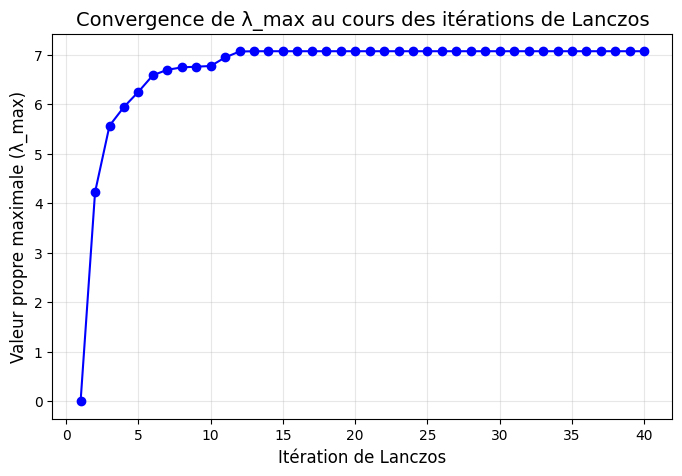

In [26]:
# tracer la convergence de lambda_max
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(lambda_max_hist) + 1), lambda_max_hist, 'o-', color='blue')
plt.xlabel('Itération de Lanczos', fontsize=12)
plt.ylabel('Valeur propre maximale (λ_max)', fontsize=12)
plt.title('Convergence de λ_max au cours des itérations de Lanczos', fontsize=14)
plt.grid(True, alpha=0.3)
plt.savefig('lanczos_convergence.png', dpi=150, bbox_inches='tight')
plt.show()